# Sesión 1: Introducción a las series temporales

En este notebook vamos a construir series temporales sintéticas para entender tendencia, estacionalidad, ruido, memoria temporal y una primera predicción baseline.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 14


## 1. Una serie temporal sintética

Primero construimos una serie diaria de ventas. Al ser sintética, conocemos sus componentes y podemos ver cómo se combinan.


In [11]:
np.random.seed(42)

fechas = pd.date_range(start="2026-01-01", periods=180, freq="D")
n = len(fechas)
dias = np.arange(n)

tendencia = np.linspace(50, 100, n)
estacionalidad = 10 * np.sin(2 * np.pi * dias / 7)
ruido = np.random.normal(loc=0, scale=5, size=n)
ventas = tendencia + estacionalidad + ruido

df = pd.DataFrame({
    "ventas": ventas,
    "tendencia": tendencia,
    "estacionalidad": estacionalidad,
    "ruido": ruido,
}, index=fechas)

df.head()


,ventas,tendencia,estacionalidad,ruido
2026-01-01,52.483571,50.000000,0.000000,2.483571
2026-01-02,57.406323,50.279330,7.818315,-0.691322
2026-01-03,63.546381,50.558659,9.749279,3.238443
2026-01-04,62.791976,50.837989,4.338837,7.615149
2026-01-05,45.607714,51.117318,-4.338837,-1.170767


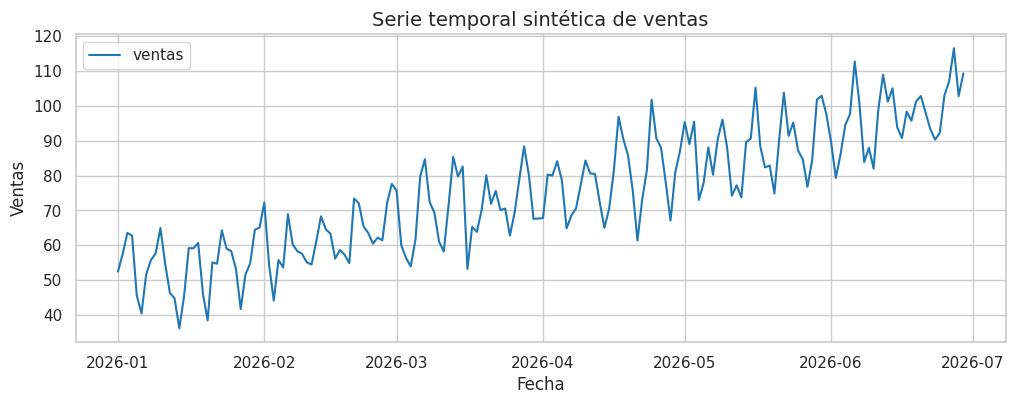

In [12]:
fig, ax = plt.subplots()
ax.plot(df.index, df["ventas"], label="ventas", color="tab:blue")
ax.set_title("Serie temporal sintética de ventas")
ax.set_xlabel("Fecha")
ax.set_ylabel("Ventas")
ax.legend()
plt.show()


## 2. Ver los componentes por separado

Separar los componentes ayuda a interpretar qué está pasando en la serie observada.


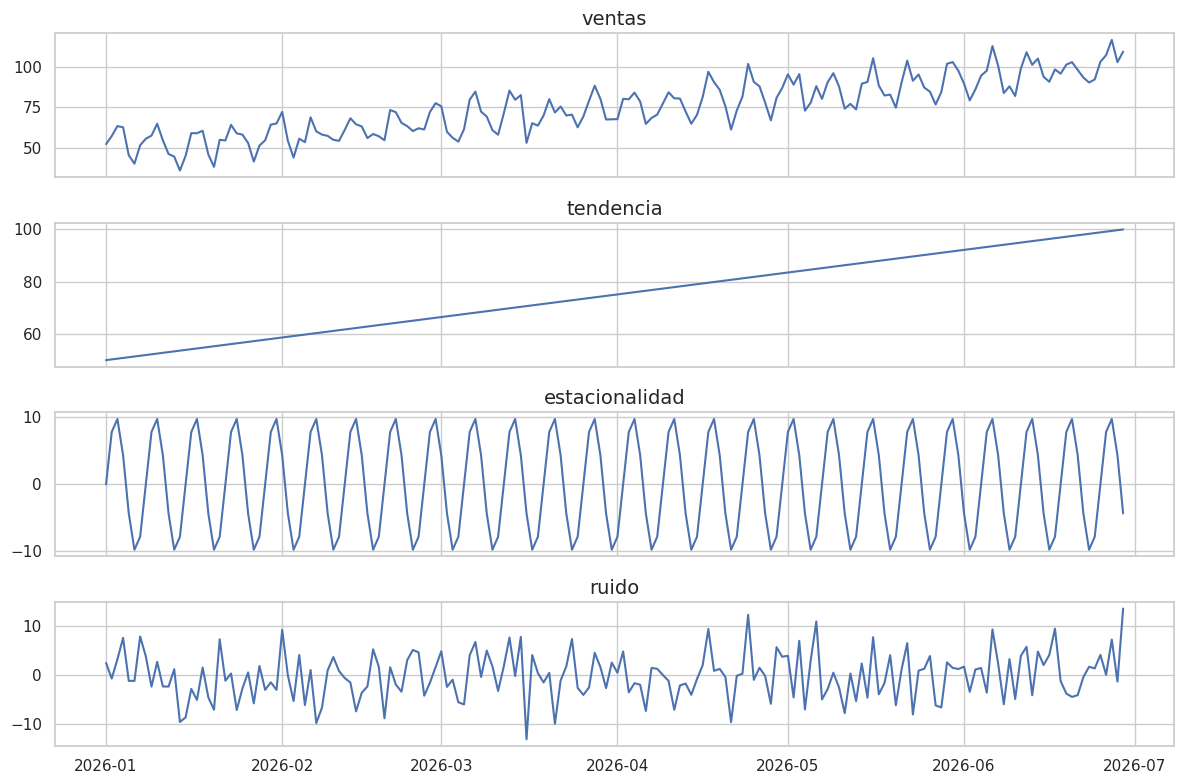

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
columnas = ["ventas", "tendencia", "estacionalidad", "ruido"]

for ax, columna in zip(axes, columnas):
    ax.plot(df.index, df[columna])
    ax.set_title(columna)

plt.tight_layout()
plt.show()


## 3. Ruido blanco y ruido rojo

El ruido blanco no tiene memoria. El ruido rojo sí depende parcialmente del valor anterior, por eso se ve más suave.


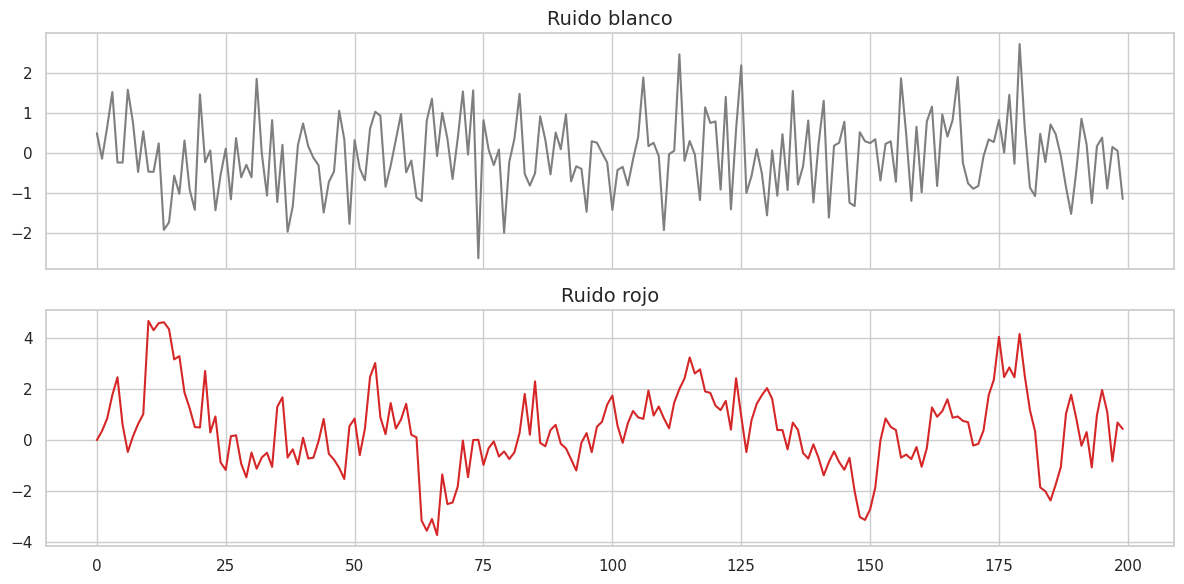

In [14]:
np.random.seed(42)
ruido_blanco = np.random.normal(0, 1, 200)

ruido_rojo = [0]
for i in range(1, 200):
    ruido_rojo.append(0.8 * ruido_rojo[i - 1] + np.random.normal(0, 1))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(ruido_blanco, color="tab:gray")
axes[0].set_title("Ruido blanco")
axes[1].plot(ruido_rojo, color="tab:red")
axes[1].set_title("Ruido rojo")
plt.tight_layout()
plt.show()


## Señales cíclicas o estacionales
Una serie tiene estacionalidad cuando repite un patrón cada cierto intervalo.

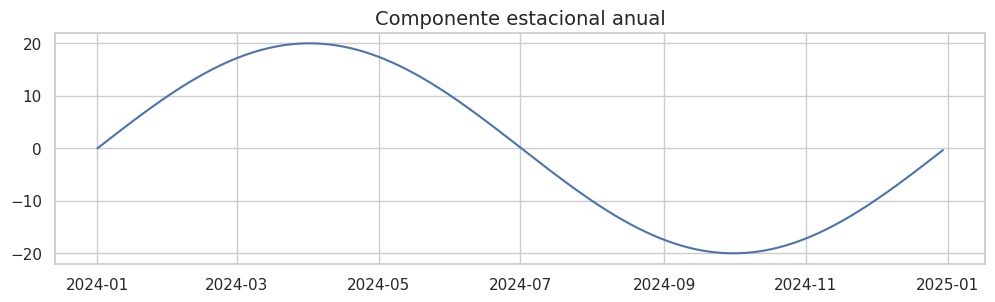

In [15]:
fechas = pd.date_range(start="2024-01-01", periods=365, freq="D")
dias = np.arange(len(fechas))
estacionalidad_anual = 20 * np.sin(2 * np.pi * dias / 365)
plt.figure(figsize=(12, 3))
plt.plot(fechas, estacionalidad_anual)
plt.title("Componente estacional anual")
plt.grid(True)
plt.show()

## 4. Serie autorregresiva

En una señal autorregresiva, el valor actual depende de valores anteriores. Esto introduce memoria temporal.


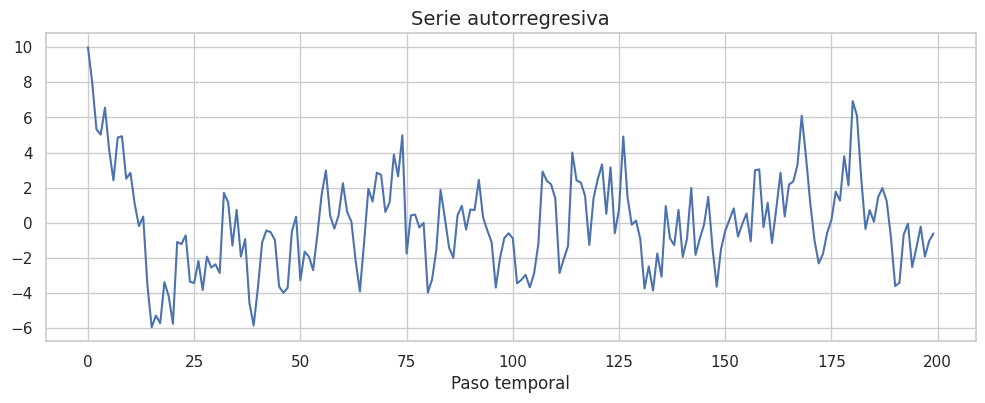

In [16]:
np.random.seed(42)
serie_ar = [10]

for i in range(1, 200):
    serie_ar.append(0.7 * serie_ar[i - 1] + np.random.normal(0, 2))

fig, ax = plt.subplots()
ax.plot(serie_ar)
ax.set_title("Serie autorregresiva")
ax.set_xlabel("Paso temporal")
plt.show()


## Mezclar componentes
En los datos reales, los componentes suelen aparecer mezclados.

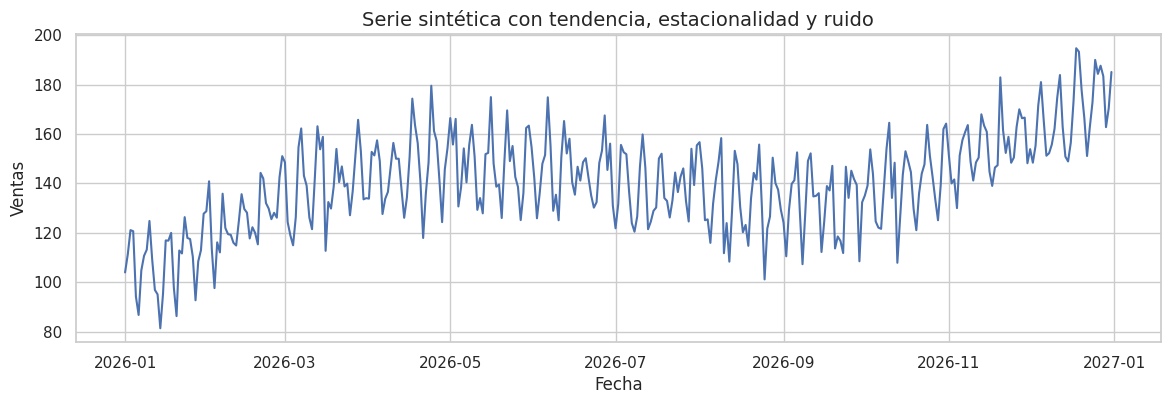

In [17]:
np.random.seed(42)
fechas = pd.date_range(start="2026-01-01", periods=365, freq="D")
n = len(fechas)
dias = np.arange(n)
tendencia = np.linspace(100, 180, n)
estacionalidad_semanal = 15 * np.sin(2 * np.pi * dias / 7)
estacionalidad_anual = 25 * np.sin(2 * np.pi * dias / 365)
ruido = np.random.normal(0, 8, n)
serie = tendencia + estacionalidad_semanal + estacionalidad_anual + ruido
df = pd.DataFrame({"ventas": serie}, index=fechas)
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["ventas"])
plt.title("Serie sintética con tendencia, estacionalidad y ruido")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()

## 5. Serie con tendencia, estacionalidad semanal y anual

En datos reales los componentes aparecen mezclados. Aquí combinamos varias fuentes de variación.


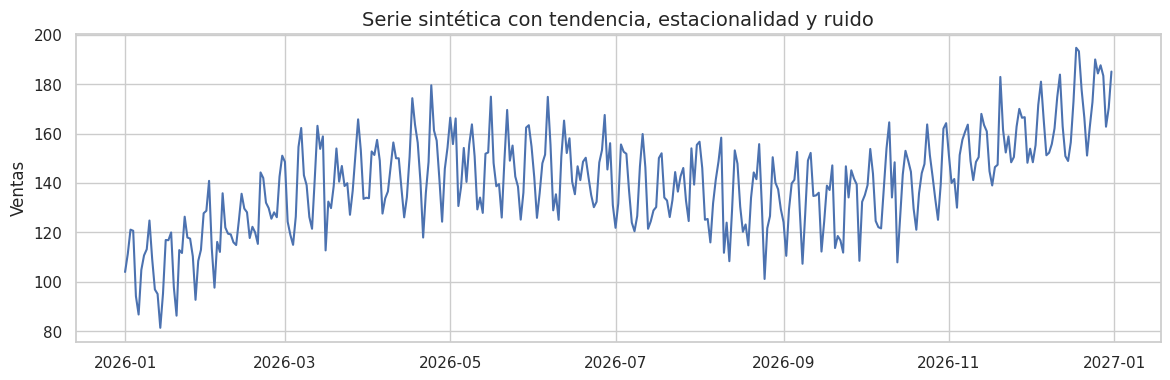

In [7]:
np.random.seed(42)
fechas = pd.date_range(start="2026-01-01", periods=365, freq="D")
n = len(fechas)
dias = np.arange(n)

tendencia = np.linspace(100, 180, n)
estacionalidad_semanal = 15 * np.sin(2 * np.pi * dias / 7)
estacionalidad_anual = 25 * np.sin(2 * np.pi * dias / 365)
ruido = np.random.normal(0, 8, n)
serie = tendencia + estacionalidad_semanal + estacionalidad_anual + ruido

df_larga = pd.DataFrame({"ventas": serie}, index=fechas)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_larga.index, df_larga["ventas"])
ax.set_title("Serie sintética con tendencia, estacionalidad y ruido")
ax.set_ylabel("Ventas")
plt.show()


## 6. Estacionaria frente a no estacionaria

Una serie no estacionaria puede cambiar su media o su varianza con el tiempo.


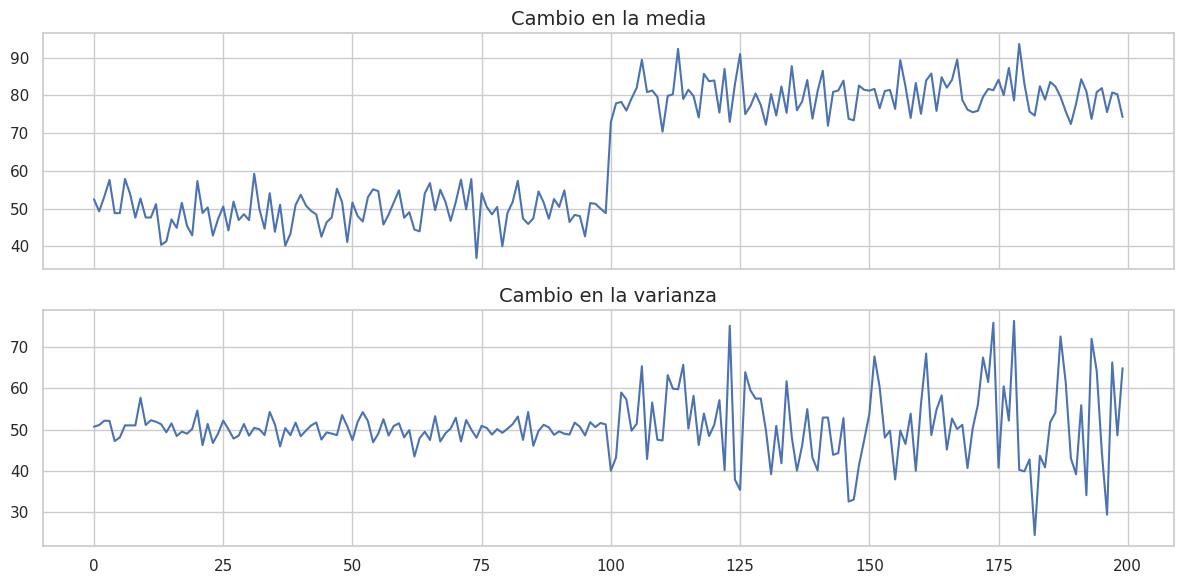

In [19]:
np.random.seed(42)
cambio_media = np.concatenate([
    np.random.normal(50, 5, 100),
    np.random.normal(80, 5, 100),
])
cambio_varianza = np.concatenate([
    np.random.normal(50, 2, 100),
    np.random.normal(50, 12, 100),
])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(cambio_media)
axes[0].set_title("Cambio en la media")
axes[1].plot(cambio_varianza)
axes[1].set_title("Cambio en la varianza")
plt.tight_layout()
plt.show()


## 7. Primera predicción baseline

Un baseline sencillo sirve como referencia mínima: predecimos todo el test con el último valor conocido.


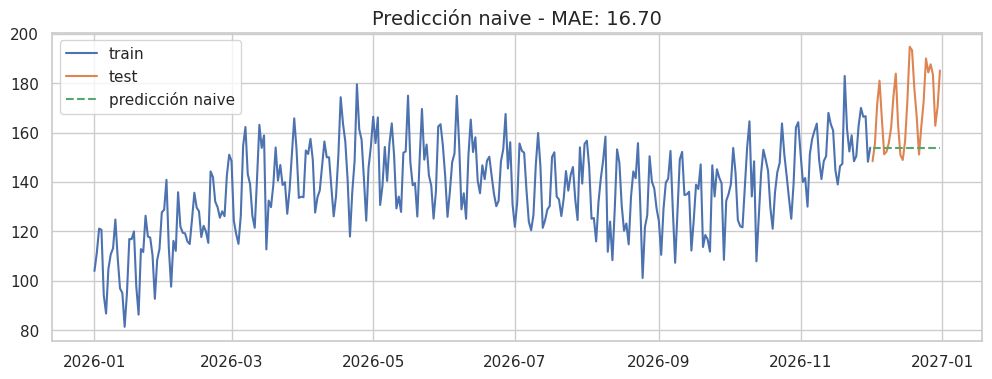

In [20]:
from sklearn.metrics import mean_absolute_error

train = df.iloc[:-30]
test = df.iloc[-30:]
pred_naive = pd.Series(train["ventas"].iloc[-1], index=test.index)
mae = mean_absolute_error(test["ventas"], pred_naive)

fig, ax = plt.subplots()
ax.plot(train.index, train["ventas"], label="train")
ax.plot(test.index, test["ventas"], label="test")
ax.plot(pred_naive.index, pred_naive, label="predicción naive", linestyle="--")
ax.set_title(f"Predicción naive - MAE: {mae:.2f}")
ax.legend()
plt.show()


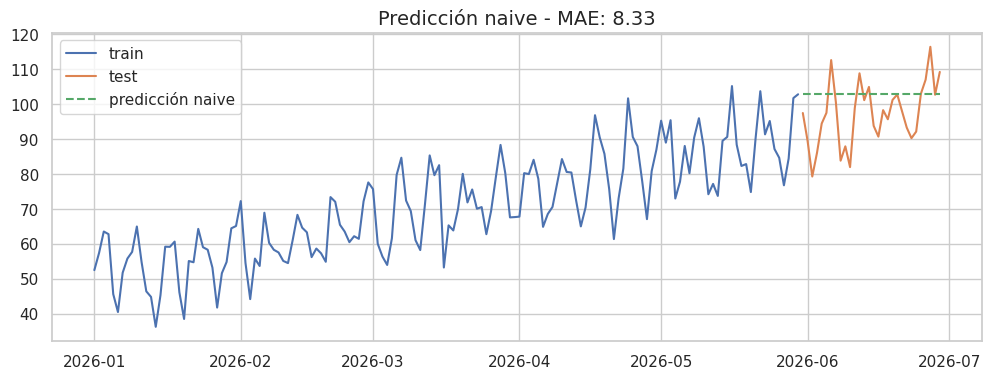

In [22]:
from sklearn.metrics import mean_absolute_error
np.random.seed(42)
fechas = pd.date_range(start="2026-01-01", periods=180, freq="D")
n = len(fechas)
dias = np.arange(n)
tendencia = np.linspace(50, 100, n)
estacionalidad = 10 * np.sin(2 * np.pi * dias / 7)
ruido = np.random.normal(0, 5, n)
ventas = tendencia + estacionalidad + ruido
df = pd.DataFrame({"ventas": ventas}, index=fechas)
train = df.iloc[:-30]
test = df.iloc[-30:]
ultimo_valor = train["ventas"].iloc[-1]
prediccion = np.repeat(ultimo_valor, len(test))
mae = mean_absolute_error(test["ventas"], prediccion)
mae
# Visualización:
plt.figure(figsize=(12, 4))
plt.plot(train.index, train["ventas"], label="train")
plt.plot(test.index, test["ventas"], label="test")
plt.plot(test.index, prediccion, label="predicción naive", linestyle="--")
plt.title(f"Predicción naive - MAE: {mae:.2f}")
plt.legend()
plt.grid(True)
plt.show()

## Actividades

1. Cambia la amplitud de la estacionalidad semanal y observa la gráfica.
2. Aumenta el ruido y comprueba cuándo la estructura deja de verse clara.
3. Sustituye la predicción naive por la media de los últimos 7 días.
